In [1]:
import pandas as pd

file_name = r'D:\Aa中工互联\工作安排\英格索兰\code\预测\lstm\data\new_history_data_0606.xlsx'
df =pd.read_excel(file_name)

In [2]:
df.columns

Index(['timestamp', 'DLDZ_DQ200_SYSTEM_PI05.PV', 'DLDZ_AVS_SYSTEM_PI05.PV',
       'DLDZ_DQ200_LLJ01_FI01.PV', 'DLDZ_AVS_LLJ01_FI01.PV', '瞬时流量', '总压力'],
      dtype='object')

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp',inplace=True)
df.head()

,DLDZ_DQ200_SYSTEM_PI05.PV,DLDZ_AVS_SYSTEM_PI05.PV,DLDZ_DQ200_LLJ01_FI01.PV,DLDZ_AVS_LLJ01_FI01.PV,瞬时流量,总压力
timestamp,,,,,,
2025-05-01 06:22:00,5.980,6.53,115.69,4.76,120.45,6.2550
2025-05-01 06:23:00,6.135,6.53,110.00,5.87,115.87,6.3325
2025-05-01 06:24:00,6.290,6.53,105.93,6.13,112.06,6.4100
2025-05-01 06:25:00,6.240,6.54,114.82,4.77,119.59,6.3900
2025-05-01 06:26:00,6.260,6.53,118.71,5.33,124.04,6.3950


In [5]:
data = df['瞬时流量'].resample('30T').mean()
data.head()

timestamp
2025-05-01 06:00:00    124.435000
2025-05-01 06:30:00    164.596333
2025-05-01 07:00:00    181.732667
2025-05-01 07:30:00    185.767000
2025-05-01 08:00:00    199.575333
Freq: 30T, Name: 瞬时流量, dtype: float64

In [6]:
data = data.ffill()

In [7]:
SAMPLING_INTERVAL = 30

In [8]:
# 计算每天有多少个数据点
points_per_day = 24 * 60 // SAMPLING_INTERVAL

print(f"成功处理数据! 数据范围: {data.index.min()} 到 {data.index.max()}")
print(f"总计 {len(data)} 个{SAMPLING_INTERVAL}分钟间隔的数据点")
print(f"每天有 {points_per_day} 个数据点")

成功处理数据! 数据范围: 2025-05-01 06:00:00 到 2025-06-06 13:30:00
总计 1744 个30分钟间隔的数据点
每天有 48 个数据点


In [ ]:
test_size = points_per_day * 10  # 1天的数据点数量
test_data = data[-test_size:]
train_data = data[:-test_size]

print(f"训练集大小: {len(train_data)} 个点 (约 {len(train_data)/points_per_day:.1f} 天)")
print(f"测试集大小: {len(test_data)} 个点 (10天)")

训练集大小: 1264 个点 (约 26.3 天)
测试集大小: 480 个点 (1天)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

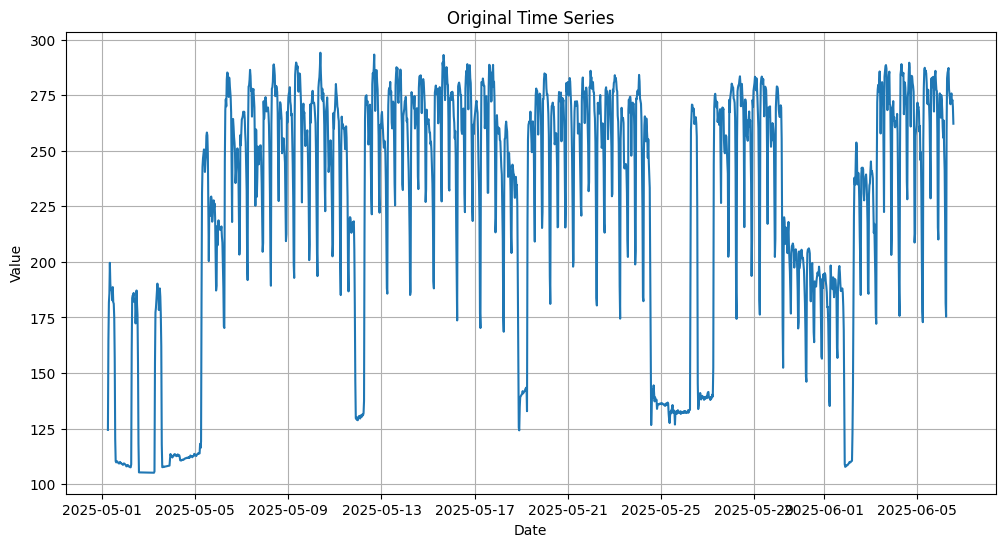

In [ ]:
# 2. 可视化原始数据
plt.figure(figsize=(12,6))
plt.plot(data)
plt.title('Original Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [15]:
train_data.head()

timestamp
2025-05-01 06:00:00    124.435000
2025-05-01 06:30:00    164.596333
2025-05-01 07:00:00    181.732667
2025-05-01 07:30:00    185.767000
2025-05-01 08:00:00    199.575333
Freq: 30T, Name: 瞬时流量, dtype: float64

In [16]:
# 3. 检查平稳性 (Augmented Dickey-Fuller检验)
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')

print("ADF Test Results:")
adf_test(train_data)

ADF Test Results:
ADF Statistic: -3.389781380831946
p-value: 0.011312195482036212
Critical Values:
   1%: -3.435621806786881
   5%: -2.8638680226791444
   10%: -2.5680094689100477


# 不平稳时，需要做差分（可选）

In [18]:
original_data = train_data.copy()

In [19]:
# 4. 如果非平稳，进行差分（通常d=1或2）
# 自动确定差分次数
d = 0
while adfuller(train_data.diff().dropna())[1] > 0.05:
    train_data = train_data.diff().dropna()
    d += 1
print(f"Suggested d (differencing order): {d}")

# 重置为原始数据
train_data = original_data

Suggested d (differencing order): 0


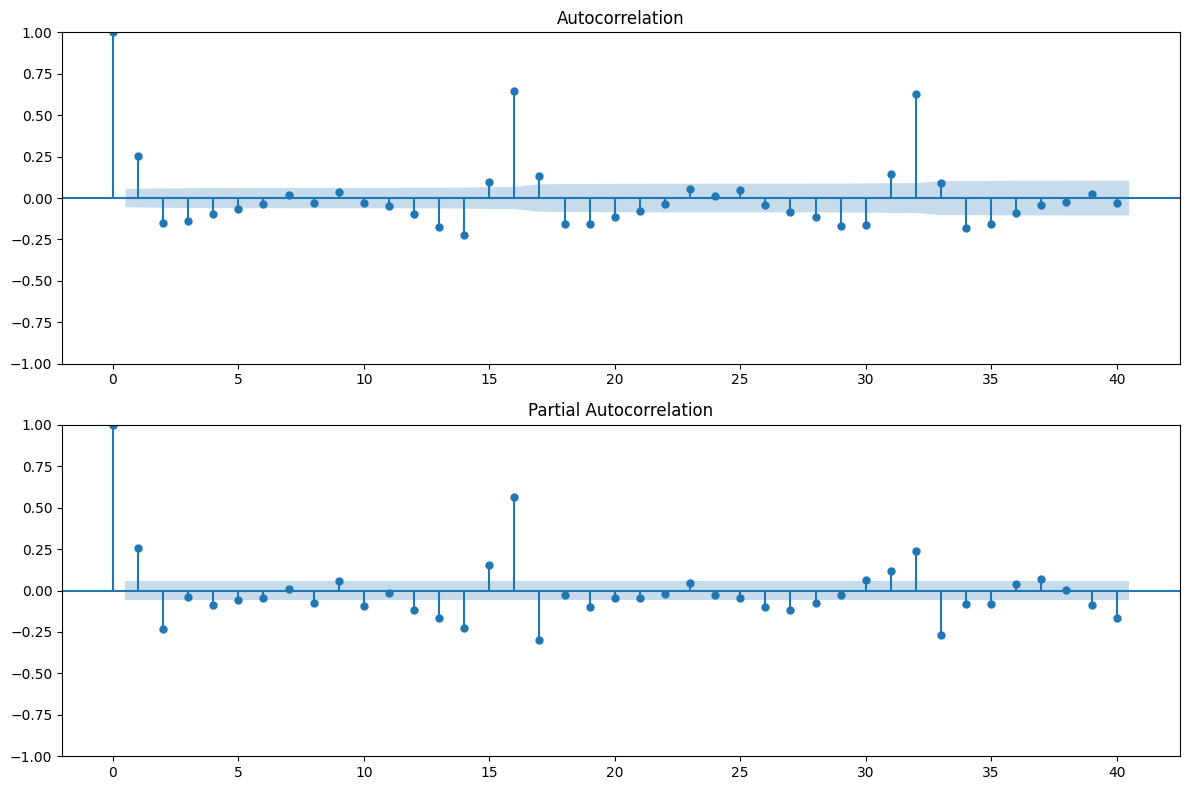

In [17]:
# 5. 分析ACF/PACF图（帮助确定p,q参数）
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(train_data.diff().dropna(), ax=plt.gca(), lags=40)
plt.subplot(212)
plot_pacf(train_data.diff().dropna(), ax=plt.gca(), lags=40)
plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 1.09 GiB for an array with shape (340, 340, 1265) and data type float64

In [ ]:
# 6. 设置模型参数（需要根据你的数据调整）
p = 1    # AR阶数
d = 1    # 差分阶数 
q = 1    # MA阶数
P = 1    # 季节性AR阶数
D = 1    # 季节性差分阶数
Q = 1    # 季节性MA阶数
s = 12   # 季节周期（月度数据常用12，季度用4）

# 7. 划分训练集/测试集
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# 8. 建立SARIMAX模型
model = SARIMAX(train['value'],
                order=(p, d, q),          # 非季节性参数
                seasonal_order=(P, D, Q, s), # 季节性参数
                enforce_stationarity=False,
                enforce_invertibility=False)

# 9. 拟合模型
results = model.fit(disp=False)
print(results.summary())

# 10. 模型诊断（检查残差）
results.plot_diagnostics(figsize=(15,12))
plt.tight_layout()
plt.show()

# 11. 进行预测
# 预测测试集
forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
confidence_int = forecast.conf_int()

# 12. 可视化预测结果
plt.figure(figsize=(12,6))
plt.plot(train.index, train['value'], label='Training Data')
plt.plot(test.index, test['value'], label='Actual Values', color='gray')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(confidence_int.index,
                 confidence_int.iloc[:,0],
                 confidence_int.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

# 13. 评估预测精度
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['value'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['value'], forecast_mean))
mape = np.mean(np.abs((test['value'] - forecast_mean) / test['value'])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# 14. 未来预测（示例：预测未来12个周期）
future_steps = 12
future_forecast = results.get_forecast(steps=len(test) + future_steps)
future_mean = future_forecast.predicted_mean[-future_steps:]
future_conf_int = future_forecast.conf_int()[-future_steps:]

# 可视化完整预测
plt.figure(figsize=(12,6))
plt.plot(df.index, df['value'], label='Historical Data')
plt.plot(future_mean.index, future_mean, label='Future Forecast', color='green')
plt.fill_between(future_conf_int.index,
                 future_conf_int.iloc[:,0],
                 future_conf_int.iloc[:,1],
                 color='lightgreen', alpha=0.3)
plt.title(f'SARIMA {future_steps}-Period Future Forecast')
plt.legend()
plt.grid(True)
plt.show()